# Reference Frames for Solar System Dynamics

#### *How* to transform between reference frames, and *why* each one reveals different dynamics.

A **reference frame** is a choice of two things: 
 - an **origin** (where is zero?), and
 - an **axis behaviour** (do the axes stay fixed, or rotate?).
Neither choice changes the physics, but it changes what a trajectory *looks like*.
The same path through space can appear as a tidy Kepler ellipse, a chaotic tangle of loops, or a stationary tadpole, depending purely on the frame you draw it in.

In this tutorial we run **one** 800-year N-body integration, store everything **once** in the inertial barycentric frame, and then derive every other view by pure post-processing (i.e. no re-integration required). 

The five frames we will visit are:

| Frame | Origin | Axes | Transformation | Best for |
|---|---|---|---|---|
| 1. Inertial barycentric | Solar System barycenter | fixed | None: this is how we store the data | precision dynamics and the Sun's wobble |
| 2. Inertial heliocentric | Sun | fixed | r − r_Sun | Kepler ellipses, MPC orbital elements |
| 3. Body-centred, non-rotating | a planet | fixed | r − r_planet | satellites and close encounters |
| 4. Co-rotating (pinned) | Sun | rotating with the planet's true longitude, θ_p | rotate by −θ_p(t) | co-orbital and resonant structure |
| 5. Uniform synodic | Sun | rotating at constant mean motion, λ(t) = λ₀ + n·t | rotate by −(λ₀ + n t) | restricted three-body theory, epicycles |

Our cast of asteroids: 

- **(469219) Kamoʻoalewa** (<span style="color:#1f77b4">■</span> `#1f77b4`) - an Earth co-orbital, famous as a "quasi-satellite"
- **(624) Hektor** (<span style="color:#7a52c7">■</span> `#7a52c7`) - the largest Jupiter Trojan, librating around the L4 Lagrange point
- **(153) Hilda** (<span style="color:#2e8b57">■</span> `#2e8b57`) - namesake of the Hilda group, locked in the 3:2 resonance with Jupiter

We will:

1. **Fetch** the orbits of all three objects from the MPC Orbits API
2. **Align** them to a common epoch with a short two-body propagation
3. **Integrate** the system once, for 800 years, storing barycentric positions
4. **Derive** all five frames from that single stored trajectory, and see what each reveals — and what each hides

Background reading: [Rotating reference frame](https://en.wikipedia.org/wiki/Rotating_reference_frame) and [Lagrange point](https://en.wikipedia.org/wiki/Lagrange_point) (Wikipedia). This notebook is a companion to the [Earth co-orbitals](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/), [Kirkwood gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) and [orbit plotting](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/) tutorials.


## Environment Setup

This notebook requires `rebound`, `mpc-orb`, `astropy`, `matplotlib`, `numpy`, and `requests`. 

We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy tqdm requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.


In [1]:
import time

import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import rebound


# Step 1: Fetch the Orbits

We query the [MPC Orbits API](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/) for each of our three objects. The API returns the orbit in `mpc_orb.json` format; here we read the fields we need directly from the JSON — the Cartesian heliocentric-ecliptic state vector (`CAR`, in AU and AU/day) and its epoch.

Note that the three orbits are **not** necessarily fit at the same epoch — at the time of writing the epochs are 61000.0 (Kamoʻoalewa) and 61200.0 (Hektor and Hilda) MJD (TT). We will deal with that in Step 2.


In [2]:
OBJECTS = {
    "469219": ("Kamo`oalewa", "Earth co-orbital"),
    "624":    ("Hektor", "Jupiter Trojan (L4)"),
    "153":    ("Hilda", "Hilda group (3:2)"),
}

def get_orbit(desig):
    """Fetch the mpc_orb.json orbit for one object from the MPC Orbits API."""
    response = requests.get("https://data.minorplanetcenter.net/api/get-orb",
                            json={"desig": desig})
    response.raise_for_status()
    result = response.json()
    if not result or not result[0].get("mpc_orb"):
        raise ValueError(f"No orbit returned for {desig!r}")
    return result[0]["mpc_orb"][0]

orbits = {desig: get_orbit(desig) for desig in OBJECTS}

# Summarize what we fetched
print(f"{'Designation':>12}  {'Name':<14}{'Class':<20}{'Epoch (MJD, TT)':>16}")
print("-" * 64)
for desig, (name, cls) in OBJECTS.items():
    epoch = orbits[desig]["epoch_data"]["epoch"]
    print(f"{desig:>12}  {name:<14}{cls:<20}{epoch:>16.1f}")


 Designation  Name          Class                Epoch (MJD, TT)
----------------------------------------------------------------
      469219  Kamo`oalewa   Earth co-orbital             61000.0
         624  Hektor        Jupiter Trojan (L4)          61200.0
         153  Hilda         Hilda group (3:2)            61200.0


# Step 2: A Common Epoch

An N-body simulation needs every particle's state at the **same instant**, so we adopt the latest of the three epochs as our common epoch and propagate the other states forward to meet it.

For this short alignment (a few hundred days at most) a simple **two-body** propagation — just the Sun and the asteroid in a throwaway REBOUND simulation — is entirely adequate: over such a short span, planetary perturbations move these orbits by far less than the resolution of any plot in this notebook. As always when mixing MPC Cartesian elements with REBOUND, we set `units = ('AU', 'day', 'Msun')` so the state vectors can be inserted without conversion.


In [3]:
COMMON_EPOCH = max(o["epoch_data"]["epoch"] for o in orbits.values())
print(f"Common epoch: {COMMON_EPOCH} MJD (TT)")

def state_at(mpc_orb, epoch):
    """Two-body propagate an mpc_orb.json Cartesian state to the given epoch."""
    state = np.array(mpc_orb["CAR"]["coefficient_values"][:6])
    dt = epoch - mpc_orb["epoch_data"]["epoch"]
    if dt == 0:
        return state
    s = rebound.Simulation()
    s.units = ("AU", "day", "Msun")
    s.add(m=1.0)
    s.add(x=state[0], y=state[1], z=state[2], vx=state[3], vy=state[4], vz=state[5])
    s.integrate(dt)
    p = s.particles[1]
    return np.array([p.x, p.y, p.z, p.vx, p.vy, p.vz])

states = {desig: state_at(o, COMMON_EPOCH) for desig, o in orbits.items()}
for desig, st in states.items():
    print(f"{OBJECTS[desig][0]:<14} r = ({st[0]:+8.4f}, {st[1]:+8.4f}, {st[2]:+8.4f}) AU")


Common epoch: 61200.0 MJD (TT)
Kamo`oalewa    r = ( -0.4716,  -0.9439,  +0.0056) AU
Hektor         r = ( -5.0443,  -0.8022,  -0.7400) AU
Hilda          r = ( +2.5264,  +3.6138,  -0.0735) AU


# Step 3: Integrate Once, in the Inertial Frame

Now we build the primary simulation: the Sun, the eight planets, and the Moon are loaded from JPL Horizons at the common epoch, and the three asteroids are added as massless test particles. Because Horizons returns positions relative to the Solar System barycenter while our MPC states are heliocentric, we add each asteroid's state **relative to the Sun particle**.

**Note on the Earth and the Moon:** we query them by their Horizons/NAIF identifiers — `"399"` for the Earth and `"301"` for the Moon — because querying by the *names* `"Earth"` or `"Moon"` resolves both to the Earth-Moon barycenter, placing two identical particles on top of each other. The [Earth co-orbitals tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/) discusses this in more detail.

The design principle of this whole notebook is worth stating in bold:

**Integrate once, store the trajectory in the inertial barycentric frame, and treat every "reference frame" as a post-processing step.** The physics happens exactly once; each of the five frames below is just a different way of *reading* the same stored numbers. This is also how professional ephemeris work is organised — the equations of motion are solved in an inertial frame, and any frame you care to plot in is derived afterwards.

We use the high-accuracy adaptive `ias15` integrator, call `move_to_com()` so the origin is the system barycenter, and sample every 1.5 days for 800 years — roughly 195,000 outputs, which takes about fifteen seconds of CPU time. At each output we store the **barycentric** (x, y) positions of the Sun, Earth, Jupiter and the three asteroids in the `bxy` dictionary.

NB: It is possible that you may experience the following error when adding planets to rebound (which uses the NASA Horizons system to extract the planetary positions): `RuntimeError: An error occured while accessing NASA HORIZONS. If this is a SSL certificate issue, you can try disabling the certificate verification by setting rebound.horizons.SSL_CONTEXT = 'unverified'.`
 - In this scenario, the simplest approach is to just retry the evaluation, and this typically will succeed.


In [4]:
# Horizons wants a Julian Date; MPC epochs are MJD
jd = COMMON_EPOCH + 2400000.5

sim = rebound.Simulation()
sim.units = ("AU", "day", "Msun")

# (query, label) pairs: "399"/"301" are the NAIF ids of the Earth and the
# Moon -- querying by name would give the Earth-Moon barycenter for both
planets = [("Sun", "Sun"), ("Mercury", "Mercury"), ("Venus", "Venus"),
           ("399", "Earth"), ("301", "Moon"), ("Mars", "Mars"),
           ("Jupiter", "Jupiter"), ("Saturn", "Saturn"),
           ("Uranus", "Uranus"), ("Neptune", "Neptune")]
for query, label in planets:
    sim.add(query, date=f"JD{jd:.6f}")
    print(f"Added {label}")

# Add the asteroids relative to the Sun particle
# (our states are heliocentric; Horizons states are barycentric)
sun0 = sim.particles[0]
for desig in OBJECTS:
    st = states[desig]
    sim.add(x=sun0.x + st[0], y=sun0.y + st[1], z=sun0.z + st[2],
            vx=sun0.vx + st[3], vy=sun0.vy + st[4], vz=sun0.vz + st[5])
    print(f"Added {OBJECTS[desig][0]}")

sim.integrator = "ias15"
sim.move_to_com()
I_SUN, I_EARTH, I_JUP, I_AST0 = 0, 3, 6, len(planets)

# Sample every 1.5 days for 800 years
n_years, dt_out = 800, 1.5
times = np.arange(0.0, n_years * 365.25, dt_out)
times_yr = times / 365.25
n_out = len(times)

# Store BARYCENTRIC (x, y) of everything interesting -- this is our
# one-and-only record of the dynamics; every frame below derives from it
bxy = {key: np.zeros((n_out, 2)) for key in
       ["sun", "earth", "jup", "kam", "hek", "hil"]}
idx = {"sun": I_SUN, "earth": I_EARTH, "jup": I_JUP,
       "kam": I_AST0, "hek": I_AST0 + 1, "hil": I_AST0 + 2}

t0 = time.time()
for k, t in enumerate(times):
    sim.integrate(t)
    for key, i in idx.items():
        p = sim.particles[i]
        bxy[key][k] = [p.x, p.y]
print(f"\nStored {n_out} outputs spanning {n_years} years "
      f"({time.time() - t0:.1f} s)")


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Added Sun
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Added Mercury
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Added Venus
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Added Earth
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Added Moon
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Added Mars
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Added Jupiter
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Added Saturn
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Added Uranus
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Added Neptune
Added Kam

### Two Tiny Helpers

Every frame in this notebook is built from just two operations on the stored barycentric positions:

- **`helio(key)`** shifts the origin to the Sun: it simply subtracts the Sun's barycentric position, `bxy[key] − bxy["sun"]`. (A body-centred frame is the same subtraction with a planet in place of the Sun.)
- **`rotate(v, theta)`** rotates a time series of 2-D vectors **by −θ**, i.e. it *undoes* a rotation θ. Rotating by −θ applies the matrix

```text
[ cos θ   sin θ ]
[ −sin θ  cos θ ]
```

so if θ(t) is a planet's longitude, `rotate(helio(key), theta)` holds that planet's direction fixed along the +x axis — which is exactly what a co-rotating frame does.


In [5]:
def helio(key):
    """Heliocentric (x, y): shift the origin from the barycenter to the Sun."""
    return bxy[key] - bxy["sun"]

def rotate(v, theta):
    """Rotate the (n, 2) array of vectors v by -theta (element-wise in time)."""
    c, s = np.cos(-theta), np.sin(-theta)
    return np.stack([c * v[:, 0] - s * v[:, 1],
                     s * v[:, 0] + c * v[:, 1]], axis=1)

AU_RSUN = 215.032  # solar radii per AU


# Step 4: Frame 1 — Inertial Barycentric: the Sun Moves Too

**How:** nothing to transform! This is the frame we stored the data in. After `move_to_com()` the Solar System barycenter sits at the origin and (by conservation of momentum) stays there — it is the inertial anchor of the whole simulation.

**Why use it:** in an inertial frame Newton's laws hold unmodified, with no fictitious forces — which is why the integration itself is done here, and why precision ephemeris work is barycentric (see the [ASSIST ephemeris-quality tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/)).

It also reveals something the heliocentric picture hides completely: **the Sun moves too.** Below we plot the Sun's own path over 60 years, with the Sun's disk drawn to scale. The Sun is displaced from the barycenter by roughly its own diameter, looping around it with Jupiter's 12-year period, modulated by Saturn. This reflex wobble is exactly the stellar motion used to infer unseen exoplanets around other stars — an alien astronomer watching the Sun wobble could deduce Jupiter's existence without ever seeing it.


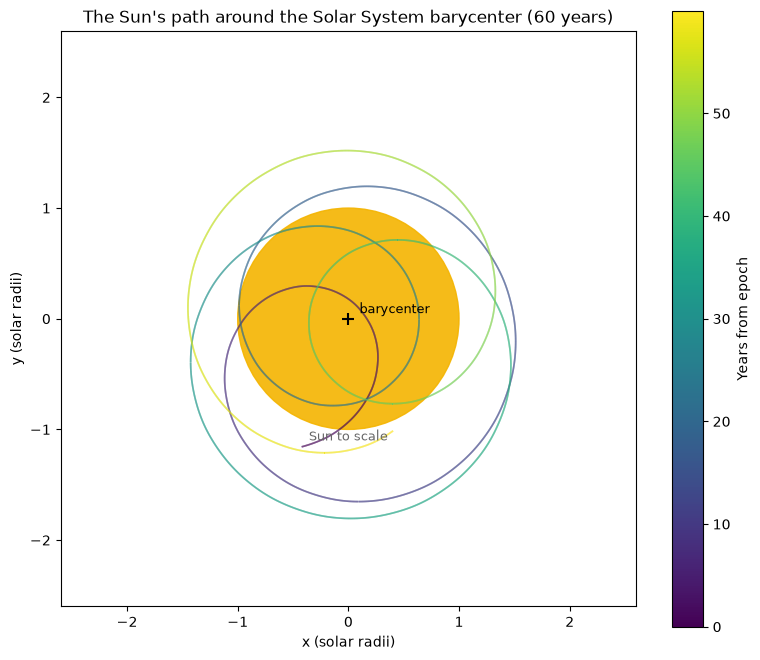

In [6]:
n60 = int(60 * 365.25 / dt_out)

fig, ax = plt.subplots(figsize=(8, 8))

# Colour the Sun's path by time using a LineCollection
pts = (bxy["sun"][:n60] * AU_RSUN).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap="viridis", array=times_yr[:n60 - 1], lw=1.2)
ax.add_collection(lc)
fig.colorbar(lc, ax=ax, shrink=0.8, label="Years from epoch")

# The Sun's disk, to scale (radius 1 in units of solar radii)
circ = plt.Circle((0, 0), 1.0, color="#f4b400", alpha=0.9, zorder=0)
ax.add_patch(circ)
ax.annotate("Sun to scale", (0, -1.1), ha="center", fontsize=9, color="0.4")

ax.scatter([0], [0], marker="+", s=80, color="black", zorder=5)
ax.annotate("barycenter", (0, 0), textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_aspect("equal")
ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
ax.set_xlabel("x (solar radii)"); ax.set_ylabel("y (solar radii)")
ax.set_title("The Sun's path around the Solar System barycenter (60 years)")
fig.tight_layout()
plt.show()


# Step 5: Frame 2 — Inertial Heliocentric: Kepler's Ellipses

**How:** shift the origin to the Sun — `helio(key) = bxy[key] − bxy["sun"]`. The axes stay fixed; only the origin moves.

**Why use it:** with the Sun at the origin, each orbit closes into (very nearly) a Kepler ellipse. This is the frame of the MPC's Cartesian elements, of classical orbital elements (a, e, i, ...), and of the earlier [orbit plotting tutorials](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/). It is the natural frame for describing *individual* orbits.

But notice what it *hides*: Kamoʻoalewa's intimate relationship with Earth, and Hektor's and Hilda's resonant lockstep with Jupiter, are completely invisible. Three unremarkable ellipses — that is all this frame will ever show you.


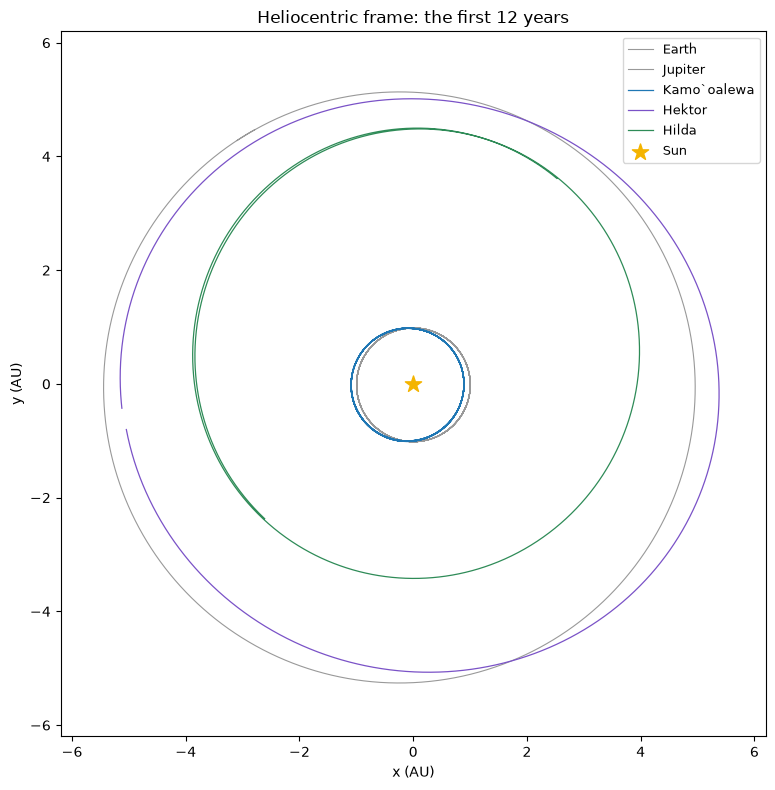

In [7]:
nYears = 12
n = int(nYears * 365.25 / dt_out)

fig, ax = plt.subplots(figsize=(8, 8))

# Planets in gray
for key, label in [("earth", "Earth"), ("jup", "Jupiter")]:
    h = helio(key)
    ax.plot(h[:n, 0], h[:n, 1], color="0.6", lw=0.8, label=label)

# Asteroids in their colours
for key, col, label in [("kam", "#1f77b4", "Kamo`oalewa"),
                        ("hek", "#7a52c7", "Hektor"),
                        ("hil", "#2e8b57", "Hilda")]:
    h = helio(key)
    ax.plot(h[:n, 0], h[:n, 1], color=col, lw=0.9, label=label)

ax.scatter([0], [0], marker="*", s=150, color="#f4b400", zorder=5, label="Sun")
ax.legend(loc="upper right", fontsize=9)
ax.set_aspect("equal")
ax.set_xlim(-6.2, 6.2); ax.set_ylim(-6.2, 6.2)
ax.set_xlabel("x (AU)"); ax.set_ylabel("y (AU)")
ax.set_title(f"Heliocentric frame: the first {nYears} years")
fig.tight_layout()
plt.show()


# Step 6: Frame 3 — Body-Centred, Non-Rotating Axes: Does It Orbit Earth?

**How:** subtract a planet instead of the Sun — here `bxy["kam"] − bxy["earth"]`. The origin now *follows Earth* around the Sun, but the axes do **not** rotate: they stay pointing at the same distant stars.

**Why use it:** this is the natural frame for anything that genuinely orbits a planet — moons, spacecraft, and temporarily-captured "mini-moons" — and for analysing close encounters.

Kamoʻoalewa is often described as a quasi-satellite "orbiting Earth", so let us test that claim honestly. The plot below shows 20 years of Kamoʻoalewa's position relative to Earth. It does stay remarkably close — within roughly 0.1 to 0.35 AU of Earth for the entire span — but look carefully at the annual loops: **they never enclose Earth**. A genuine satellite's path would encircle the origin; Kamoʻoalewa's loops always keep Earth outside them. In inertial axes, Kamoʻoalewa does *not* go around us — it goes around the Sun, staying near Earth. The popular picture of a quasi-satellite tracing a retrograde orbit "around" Earth belongs to the **rotating** frame of the next step.


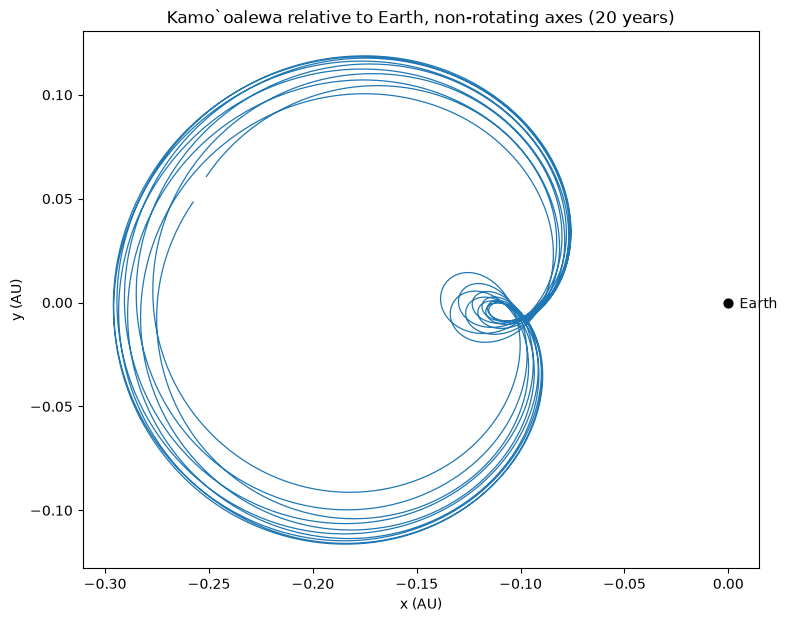

In [8]:
nYears = 10
nSteps = int(nYears * 365.25 / dt_out)
geo = bxy["kam"] - bxy["earth"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(geo[:nSteps, 0], geo[:nSteps, 1], color="#1f77b4", lw=0.9)
ax.scatter([0], [0], s=40, color="black", zorder=5)
ax.annotate("Earth", (0, 0), textcoords="offset points", xytext=(8, -4), fontsize=10)
ax.set_aspect("equal")
ax.set_xlabel("x (AU)"); ax.set_ylabel("y (AU)")
ax.set_title("Kamo`oalewa relative to Earth, non-rotating axes (20 years)")
fig.tight_layout()
plt.show()


# Step 7: Frame 4 — Co-Rotating with a Planet: Resonances Stand Still

**How:** keep the Sun at the origin, but let the axes turn with a planet. At each output we compute the planet's true longitude θ_p = arctan2(y_p, x_p) and rotate *every* heliocentric position vector by −θ_p, i.e. apply

```text
[ cos θ_p   sin θ_p ]
[ −sin θ_p  cos θ_p ]
```

This pins the planet to the +x axis: the planet barely moves, and everything else is drawn *relative to the Sun-planet line*.

**Why use it:** mean-motion resonances are relationships between an asteroid and a *planet*, so they only become visible in a frame where the planet stands still. First, Kamoʻoalewa in the frame co-rotating with **Earth** — and here, at last, are the famous quasi-satellite loops that seem to encircle Earth. (For the full story of Earth's co-orbital menagerie — quasi-satellites, horseshoes and tadpoles — see the [Earth co-orbitals tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/).)


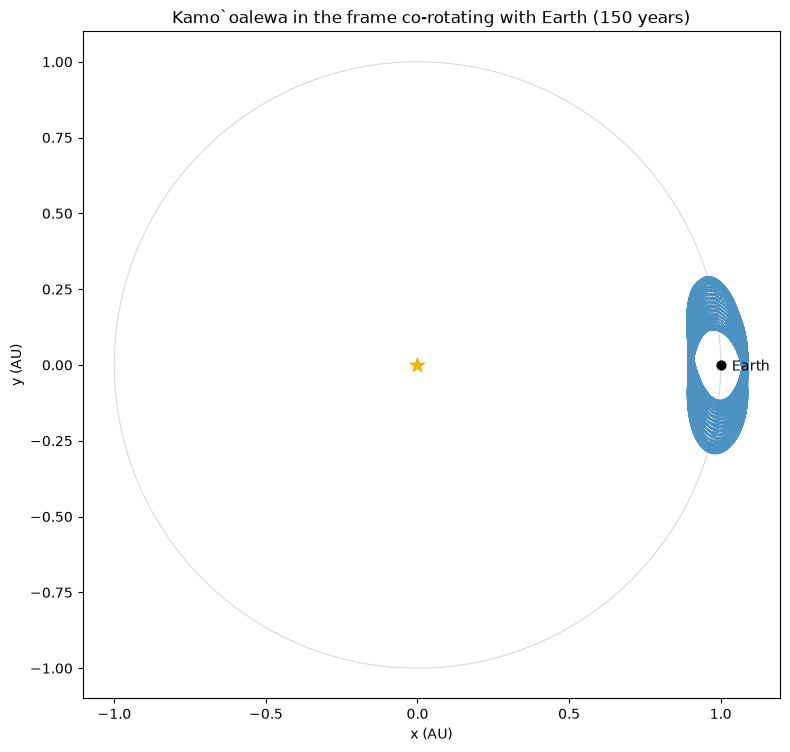

In [9]:
# Earth's true longitude at each output, and the rotation that pins it
theta_e = np.arctan2(helio("earth")[:, 1], helio("earth")[:, 0])
kam_rot = rotate(helio("kam"), theta_e)

n150 = int(150 * 365.25 / dt_out)
th = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(np.cos(th), np.sin(th), color="0.85", lw=0.8, zorder=0)  # Earth's orbit
ax.plot(kam_rot[:n150, 0], kam_rot[:n150, 1], color="#1f77b4", lw=0.5, alpha=0.8)
ax.scatter([1], [0], s=40, color="black", zorder=5)
ax.annotate("Earth", (1, 0), textcoords="offset points", xytext=(8, -4), fontsize=10)
ax.scatter([0], [0], marker="*", s=110, color="#f4b400", zorder=5)
ax.set_aspect("equal")
ax.set_xlabel("x (AU)"); ax.set_ylabel("y (AU)")
ax.set_title("Kamo`oalewa in the frame co-rotating with Earth (150 years)")
fig.tight_layout()
plt.show()


Now the same trick with **Jupiter**, applied to our two resonant asteroids over the full 800 years:

- **Hektor**, a Trojan in the 1:1 resonance, traces a compact **tadpole** hugging the L4 point, 60 degrees ahead of Jupiter — it librates gently about L4 and never strays far.
- **Hilda**, in the 3:2 resonance, traces something more surprising: a **triangle** with rounded vertices at L4, L3 and L5. The geometry is exact bookkeeping: in the 3:2 resonance Hilda reaches aphelion three times for every two Jupiter orbits, and those successive aphelia land at L4, then L3, then L5 — always at the corners farthest from Jupiter itself. Perihelion passages, where Hilda swings inside, happen when Jupiter is safely elsewhere. This protected geometry is what lets the entire Hilda population survive on Jupiter-approaching orbits; the spectacular *population* version of this picture (hundreds of Hildas lighting up the whole triangle at once) is in the [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/).


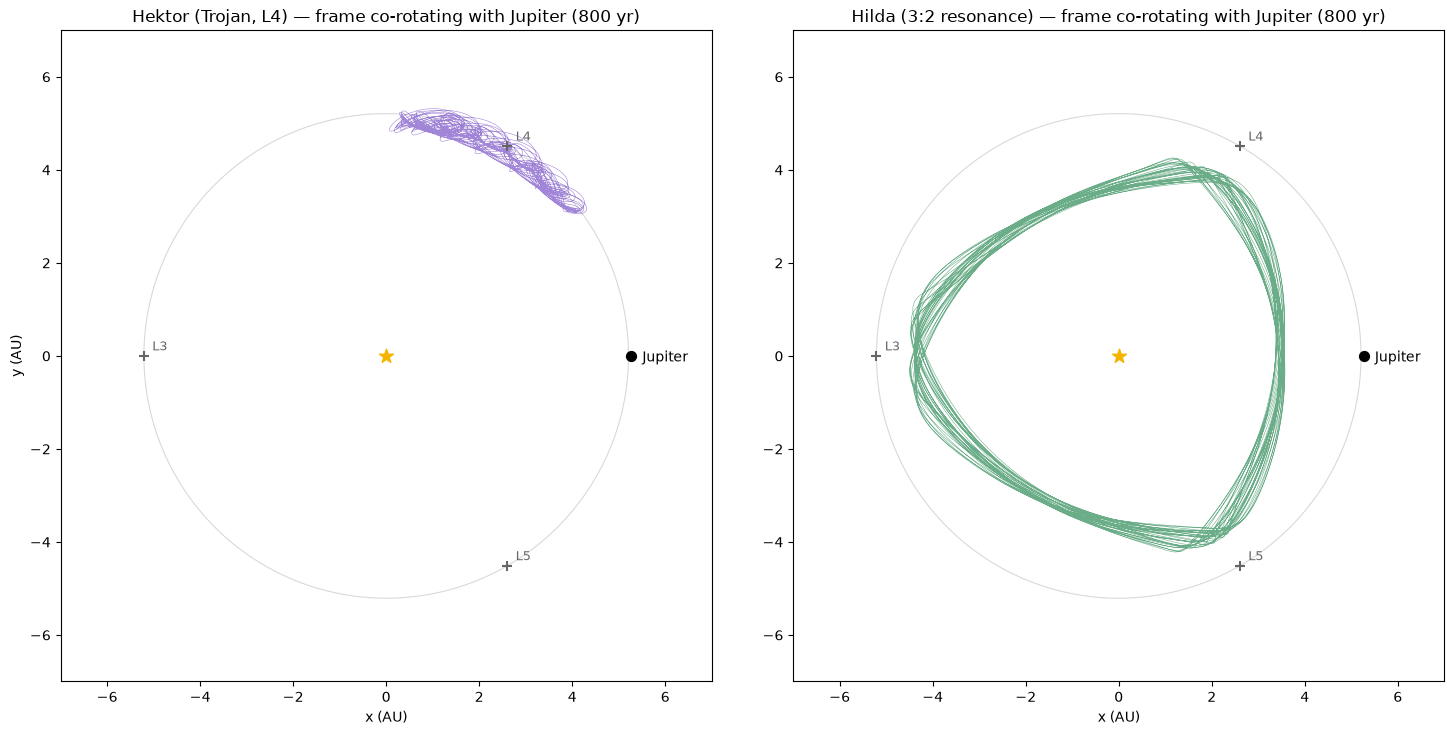

In [10]:
# Jupiter's true longitude, and every heliocentric track rotated to pin it
theta_j = np.arctan2(helio("jup")[:, 1], helio("jup")[:, 0])
hek_rot = rotate(helio("hek"), theta_j)
hil_rot = rotate(helio("hil"), theta_j)
jup_rot = rotate(helio("jup"), theta_j)

a_j = np.hypot(*helio("jup").T).mean()   # Jupiter's mean distance, for the guide circle
th = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
for ax, dat, col, name in [(axes[0], hek_rot, "#7a52c7", "Hektor (Trojan, L4)"),
                           (axes[1], hil_rot, "#2e8b57", "Hilda (3:2 resonance)")]:
    ax.plot(a_j * np.cos(th), a_j * np.sin(th), color="0.85", lw=0.8, zorder=0)
    ax.plot(dat[:, 0], dat[:, 1], color=col, lw=0.4, alpha=0.7)
    ax.scatter(jup_rot[0, 0], jup_rot[0, 1], s=50, color="black", zorder=5)
    ax.annotate("Jupiter", (jup_rot[0, 0], jup_rot[0, 1]),
                textcoords="offset points", xytext=(8, -4), fontsize=10)
    ax.scatter([0], [0], marker="*", s=110, color="#f4b400", zorder=5)
    for ang, lab in [(60, "L4"), (-60, "L5"), (180, "L3")]:
        xx = a_j * np.cos(np.radians(ang))
        yy = a_j * np.sin(np.radians(ang))
        ax.scatter([xx], [yy], marker="+", s=60, color="0.4", zorder=4)
        ax.annotate(lab, (xx, yy), textcoords="offset points", xytext=(6, 4),
                    fontsize=9, color="0.4")
    ax.set_aspect("equal")
    ax.set_xlim(-7, 7); ax.set_ylim(-7, 7)
    ax.set_title(f"{name} — frame co-rotating with Jupiter (800 yr)")
    ax.set_xlabel("x (AU)")
axes[0].set_ylabel("y (AU)")
fig.tight_layout()
plt.show()


# Step 8: Frame 5 — the Uniform Synodic Frame: Theory's Choice

The pinned frame above rotated with Jupiter's *true* longitude, which speeds up and slows down as Jupiter moves along its (slightly eccentric) ellipse. Theorists prefer a subtly different frame: one that rotates at **constant** angular rate — the planet's mean motion. This is the *uniform synodic frame*.

**How:** we need the best-fitting uniform rotation λ(t) = λ₀ + n t through Jupiter's longitude. One subtlety: `arctan2` returns angles wrapped to (−π, π], and you cannot fit a straight line through a sawtooth — the longitude must be **unwrapped** first (`np.unwrap`) so it grows continuously through hundreds of revolutions. A least-squares straight-line fit via `np.linalg.lstsq` then recovers Jupiter's mean motion — the fitted period comes out at 11.86 years, as it should — and we rotate by −λ(t).

**Why use it:** a frame rotating at constant rate is the frame of **circular restricted three-body theory**, in which the Jacobi constant is conserved and zero-velocity curves are defined. The pinned frame is prettier for plots, but it silently *absorbs the planet's own eccentricity* into the frame rotation — which is precisely the thing theory needs to keep visible.

The figure below shows the difference using Jupiter itself, over 24 years (two Jupiter orbits). In the **uniform** frame Jupiter is not a fixed dot: it traces its *eccentricity epicycle*, a small 2:1 ellipse with semi-axes a·e ≈ 0.25 AU in the radial direction by 2a·e ≈ 0.51 AU along-track. In the **pinned** frame the same motion collapses onto the +x axis: Jupiter is held at zero longitude by construction, and only its distance from the Sun breathes in and out.


Jupiter mean motion fit -> period 11.862 yr


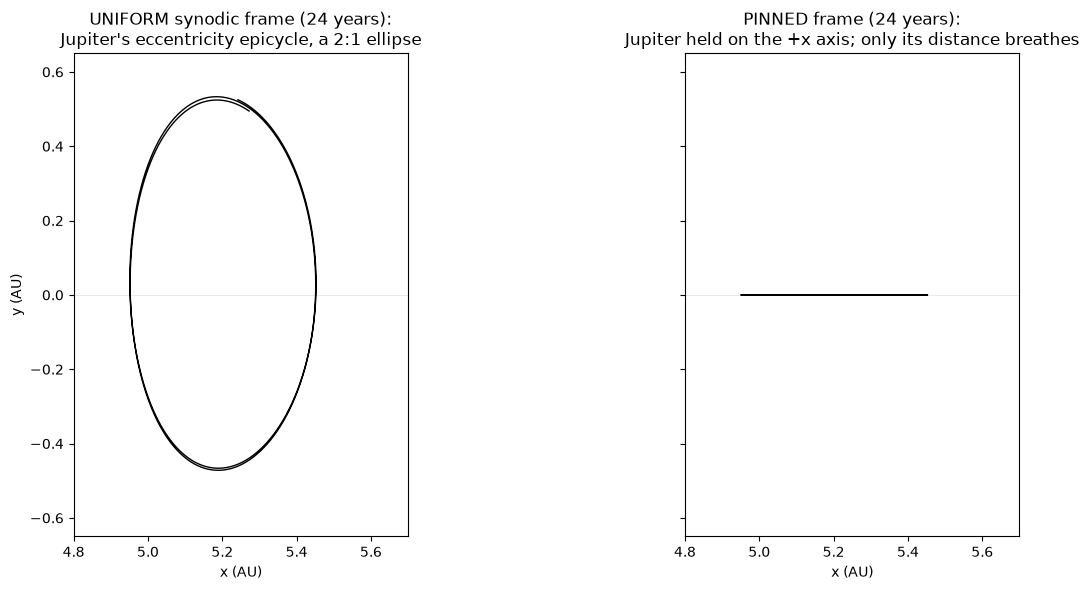

In [11]:
# Fit lambda(t) = lambda_0 + n*t to Jupiter's UNWRAPPED longitude
theta_u = np.unwrap(theta_j)
A = np.vstack([times, np.ones_like(times)]).T
(n_mean, lam0), *_ = np.linalg.lstsq(A, theta_u, rcond=None)
theta_lin = lam0 + n_mean * times
print(f"Jupiter mean motion fit -> period {2 * np.pi / n_mean / 365.25:.3f} yr")

jup_uni = rotate(helio("jup"), theta_lin)

n24 = int(24 * 365.25 / dt_out)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
axes[0].plot(jup_uni[:n24, 0], jup_uni[:n24, 1], color="black", lw=1.0)
axes[0].set_title("UNIFORM synodic frame (24 years):\n"
                  "Jupiter's eccentricity epicycle, a 2:1 ellipse")
axes[1].plot(jup_rot[:n24, 0], jup_rot[:n24, 1], color="black", lw=1.2)
axes[1].set_title("PINNED frame (24 years):\n"
                  "Jupiter held on the +x axis; only its distance breathes")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x (AU)")
    ax.axhline(0, color="0.9", lw=0.6, zorder=0)
axes[0].set_ylabel("y (AU)")
axes[0].set_xlim(4.8, 5.7)
axes[0].set_ylim(-0.65, 0.65)
fig.tight_layout()
plt.show()


Neither frame is "right". The pinned frame makes the prettiest pictures of libration; the uniform frame is where the theory lives. Choose the one that makes *your* question easy — and know what your choice is hiding.


# Choosing a Frame

The same 800 years of stored barycentric positions gave us all five views. One-line verdicts:

| Frame | Verdict |
|---|---|
| 1. Inertial barycentric | The frame of the *physics*: integrate here; it alone shows the Sun's exoplanet-style wobble. |
| 2. Inertial heliocentric | The frame of the *catalogue*: clean Kepler ellipses and MPC orbital elements, but resonances are invisible. |
| 3. Body-centred, non-rotating | The frame of *satellites*: the honest test of "does it actually orbit the planet?" (Kamoʻoalewa does not). |
| 4. Co-rotating (pinned) | The frame of *resonance*: tadpoles, quasi-satellite loops and Hilda's triangle stand still and reveal themselves. |
| 5. Uniform synodic | The frame of *theory*: constant rotation rate, the Jacobi constant, and the eccentricity epicycle laid bare. |

The rule of thumb: **inertial frames for forces and ellipses; body-centred frames for satellites and encounters; rotating frames for resonance — and always know what your frame is hiding.**


# Going Further

Some ideas for extending this notebook:

- **The rotating-pulsating frame** of the elliptic restricted three-body problem: rotate with the planet *and* rescale lengths by the instantaneous Sun-planet distance, so that the planet is pinned at exactly (1, 0) even on an eccentric orbit — the frame in which the elliptic problem's Lagrange points stand still.
- **The invariable plane**: our plots used the ecliptic (x, y) plane, but the dynamically preferred plane of the Solar System is the one perpendicular to its total angular momentum.
- **Axis orientation** is a choice we quietly held fixed: all frames here used ecliptic axes, but equatorial axes are equally valid — see the conversion table in the [ASSIST tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/).
- **Animate any of these frames**: an animated co-rotating frame makes libration mesmerising to watch.
- **Repeat Frame 4 for Venus or Mars**: both planets host their own co-orbital companions waiting in the MPC catalogue.


# Summary

In this tutorial we:

1. **Fetched** the orbits of (469219) Kamoʻoalewa, (624) Hektor and (153) Hilda from the MPC Orbits API
2. **Aligned** their Cartesian state vectors to a common epoch with a short two-body propagation
3. **Integrated** the system exactly once — 800 years with REBOUND's `ias15` integrator — and stored the trajectory in the inertial barycentric frame
4. **Derived** five reference frames from that single stored trajectory, by nothing more than subtracting an origin and rotating axes
5. **Saw** what each frame reveals: the Sun's barycentric wobble, Kepler's heliocentric ellipses, the honest geocentric answer to "does Kamoʻoalewa orbit Earth?" (no), Hektor's tadpole and Hilda's L4-L3-L5 triangle in the co-rotating frame, and Jupiter's 2:1 eccentricity epicycle in the uniform synodic frame
6. **Distilled** a rule of thumb: inertial frames for forces and ellipses, body-centred frames for satellites and encounters, rotating frames for resonance

### Further Resources

- [Rotating reference frame](https://en.wikipedia.org/wiki/Rotating_reference_frame) and [Lagrange point](https://en.wikipedia.org/wiki/Lagrange_point) (Wikipedia)
- Murray & Dermott, *Solar System Dynamics* — the standard text for resonance and the restricted three-body problem
- [From MPC Orbit to N-Body Simulation with Rebound](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [Ephemeris-quality integrations with ASSIST](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/)
- [Visualising orbits from the MPC database](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/)
- [The Kirkwood gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/)
- [Earth's co-orbital companions](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/)
- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).
